# Colab 5 — Human in the Loop with `interrupt()`

**Goal:** Pause when an order ID is missing, save state, and resume with human input.


In [1]:
!pip -q install -U langgraph


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 4.0 MB/s eta 0:00:00


In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command

class State(TypedDict):
    request: str
    order_id: str
    response: str

ORDERS = {
    "ORD102": "Shipped — estimated delivery tomorrow",
    "ORD103": "Delayed — carrier weather disruption",
}

def support_agent(state: State):
    order_id = state.get("order_id", "")
    if not order_id:
        order_id = interrupt({
            "question": "What is your order ID?",
            "example": "ORD102"
        })

    status = ORDERS.get(order_id, "Order not found")
    return {
        "order_id": order_id,
        "response": f"{order_id}: {status}"
    }

builder = StateGraph(State)
builder.add_node("support_agent", support_agent)
builder.add_edge(START, "support_agent")
builder.add_edge("support_agent", END)

graph = builder.compile(checkpointer=InMemorySaver())
config = {"configurable": {"thread_id": "customer-1"}} # must

paused = graph.invoke({
    "request": "Where is my order.?",
    "order_id": "",
    "response": ""
}, config=config)

paused


{'request': 'Where is my order.?',
 'order_id': '',
 'response': '',
 '__interrupt__': [Interrupt(value={'question': 'What is your order ID?', 'example': 'ORD102'}, id='ac15b40586e02c6c1a002af2d921c75a', response_schema=None)]}

In [3]:
# Resume the SAME thread.
completed = graph.invoke(
    Command(resume="ORD102"),
    config=config
)
completed


{'request': 'Where is my order.?',
 'order_id': 'ORD102',
 'response': 'ORD102: Shipped — estimated delivery tomorrow'}

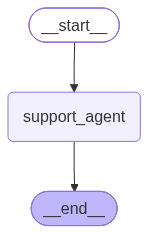

In [4]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Takeaway

> “`interrupt()` looks like a normal function call, but its return value arrives later. The same `thread_id` tells LangGraph which saved execution to continue.”

Important: the node restarts from its beginning when resumed, so code before `interrupt()` must be safe to run again.
